In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

# 📦 Install and fix dependencies
import sys, subprocess

# Update package lists
subprocess.run(['apt-get', 'update', '-qq'], check=True)

# Install ffmpeg for audio processing
subprocess.run(['apt-get', 'install', '-y', '-qq', 'ffmpeg'], check=True)

# Install required Python packages
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'SpeechRecognition', 'torch', 'datasets', 'scikit-learn', 'evaluate'
], check=True)

print("✅ Dependencies installed.")

Mounted at /content/gdrive
✅ Dependencies installed.


Found existing installation: transformers 4.51.3
Uninstalling transformers-4.51.3:
  Successfully uninstalled transformers-4.51.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 76.1 MB/s eta 0:00:00


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Map:   0%|          | 0/304 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
10,1.130000
20,0.699500
30,0.584900
40,0.226100
50,0.247900
60,0.059800
70,0.072900
80,0.053200
90,0.168500
100,0.020700


📊 Evaluation Metrics: {'eval_loss': 0.010743321850895882, 'eval_accuracy': 0.9967105263157895, 'eval_precision': 0.9967714424951267, 'eval_recall': 0.9967105263157895, 'eval_f1': 0.996719344951723, 'eval_runtime': 1.3115, 'eval_samples_per_second': 231.799, 'eval_steps_per_second': 28.975, 'epoch': 5.0}


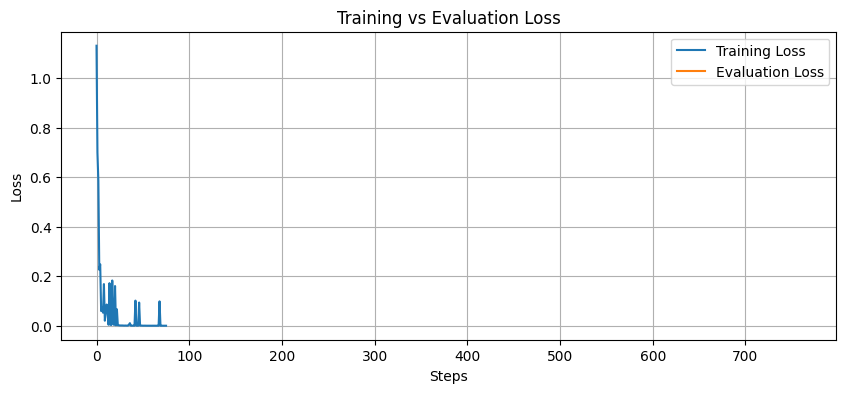

In [ ]:
!pip uninstall -y transformers
!pip install -q transformers --upgrade


# ✅ Imports / Import libraries for dataset handling, tokenization, model training, and evaluation
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import transformers

# 📁 Load and process dataset

# Load dataset from CSV file
df = pd.read_csv("/content/gdrive/MyDrive/Dataset_2.csv")
# Ensure 'sentence' column is of string type
df['sentence'] = df['sentence'].astype(str)

# Encode sentiment labels using LabelEncoder
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

# Create Hugging Face Dataset from pandas DataFrame
dataset = Dataset.from_pandas(df[['sentence', 'label']].reset_index(drop=True))
# Split dataset into train and test sets
dataset = dataset.train_test_split(test_size=0.2, seed=42)
# Create a DatasetDict for easier management
dataset_dict = DatasetDict({
    'train': dataset['train'],
    'test': dataset['test']
})

# 🔤 Tokenization
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load the tokenizer
def tokenize_fn(example):
    return tokenizer(example["sentence"], padding="max_length", truncation=True)

encoded_dataset = dataset_dict.map(tokenize_fn, batched=True, remove_columns=["sentence"])

# 🧠 Load model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=len(label_encoder.classes_)
)

# 🧪 Metrics
# Define a function to compute evaluation metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# ⚙️ Training settings (improved)
# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_steps=100,
    save_steps=100,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    report_to='none',
    fp16=True,
)

# 🏋️ Trainer with early stopping
# Create a Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["test"],
    compute_metrics=compute_metrics,
)


# 🚀 Train
trainer.train()

# 🧪 Evaluate
metrics = trainer.evaluate()
print("📊 Evaluation Metrics:", metrics)

# 💾 Save
model.save_pretrained("sentiment_model")
tokenizer.save_pretrained("sentiment_model")

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)


# Extract training and evaluation metrics from logs
log_history = trainer.state.log_history
train_loss = [log["loss"] for log in log_history if "loss" in log]
eval_loss = [log["eval_loss"] for log in log_history if "eval_loss" in log]
eval_accuracy = [log["eval_accuracy"] for log in log_history if "eval_accuracy" in log]
eval_steps = [log["step"] for log in log_history if "eval_loss" in log]

# Create and display plots of training and evaluation metrics
plt.figure(figsize=(10, 4))
plt.plot(train_loss, label="Training Loss")
plt.plot(eval_steps, eval_loss, label="Evaluation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Evaluation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Import necessary libraries for audio recording and processing
from IPython.display import HTML, Javascript, display
from google.colab import output
import base64
import speech_recognition as sr
import subprocess

# Define a function to save audio data from the browser
def _save_audio(b64):
    data = base64.b64decode(b64)
    with open('recorded.webm', 'wb') as f:
        f.write(data)
output.register_callback('notebook.saveAudio', _save_audio)

# Display UI buttons for recording audio
display(HTML('''
  <button onclick="startRecording()">🎤 Start Recording</button>
  <button onclick="stopRecording()">⏹️ Stop Recording</button>
  <span id="status">Status: Idle</span>
'''))

# Display JavaScript code to handle audio recording in the browser
display(Javascript("""
(async function() {
  let recorder, stream, chunks;
  window.startRecording = async () => {
    stream = await navigator.mediaDevices.getUserMedia({audio:true});
    recorder = new MediaRecorder(stream);
    chunks = [];
    recorder.ondataavailable = e => chunks.push(e.data);
    recorder.onstart = () => {
      document.getElementById('status').innerText = 'Status: Recording…';
    };
    recorder.onstop = () => {
      document.getElementById('status').innerText = 'Status: Processing…';
      const blob = new Blob(chunks, {type:'audio/webm'});
      const reader = new FileReader();
      reader.readAsDataURL(blob);
      reader.onloadend = () => {
        const b64 = reader.result.split(',')[1];
        google.colab.kernel.invokeFunction('notebook.saveAudio', [b64], {});
        document.getElementById('status').innerText = 'Status: Saved ✅';
      };
      stream.getTracks().forEach(t => t.stop());
    };
    recorder.start();
  };
  window.stopRecording = () => recorder && recorder.state === 'recording' && recorder.stop();
})()
"""))


<IPython.core.display.Javascript object>

In [ ]:
# Convert recorded audio to WAV format for transcription
subprocess.run(['ffmpeg', '-i', 'recorded.webm', 'recorded.wav', '-y'], check=True)

# Initialize speech recognizer
recognizer = sr.Recognizer()
# Load audio file and transcribe speech
with sr.AudioFile('recorded.wav') as src:
    audio_data = recognizer.record(src)

# Attempt speech recognition
try:
    transcript = recognizer.recognize_google(audio_data)
except:
    transcript = ""

# Print the transcribed text
print("🎙️ Transcript:")
print(transcript or "(No speech detected)")


🎙️ Transcript:
today is one of my best day ever I want to commit the suicide


In [ ]:
from transformers import pipeline
import pickle

# Load model and tokenizer
model_path = "sentiment_model"
sentiment_analyzer = pipeline("text-classification", model=model_path, tokenizer=model_path)

# Load label encoder
with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

# Run sentiment analysis
result = sentiment_analyzer(transcript)[0] if transcript else {"label": None, "score": None}

# Decode prediction label
if result["label"] and result["label"].startswith("LABEL_"):
    label_index = int(result["label"].split("_")[1])
    decoded_label = label_encoder.inverse_transform([label_index])[0]
else:
    decoded_label = None

# --- Display Results ---

print("\n" + "="*50)
print("📝 Transcript Analysis")
print("="*50)
print(f"📄 Sentence: {transcript if transcript else '(No speech detected)'}")

print("\n" + "="*50)
print("📊 Sentiment Analysis")
print("="*50)
if decoded_label:
    print(f" • Sentiment Detected : {decoded_label}")
    print(f" • Confidence Score   : {result['score']:.2f}")

    # Check if negative sentiment exceeds 60%
    if decoded_label.lower() == "negative" and result['score'] > 0.6:
        print("\n🚨 ALERT: Patient at risk")
        print("\n🏥 Action: Refer to therapy if negative sentiment persists")

else:
    print(" • No sentiment detected.")

# --- Self-Harm Keyword Detection ---
self_harm_keywords = [
    "suicide", "commit suicide", "attempt suicide", "kill myself", "going to kill myself", "want to kill myself",
    "thinking about killing myself", "off myself", "end it all", "end my life", "finish it all", "finish myself off",
    "hang myself", "overdose", "overdose on pills", "take pills", "swallow pills", "slit my wrists", "slash my arms",
    "cut myself", "self harm", "self-harm", "hurt myself", "want to hurt myself", "cause myself pain", "i'm worthless",
    "worthless", "not worth living", "life isn't worth living", "no reason to live", "what's the point anymore",
    "feel like dying", "feeling suicidal", "suicidal thoughts", "suicidal ideation", "want it to end", "wish i were dead",
    "wish i was dead", "hope i'm dead", "death can't come soon enough", "ready to die", "can't go on", "can't keep living",
    "don't want to exist", "don't want to be here", "vanish forever", "disappear forever", "blow my brains out",
    "shoot myself", "put a bullet in my head", "please kill me", "kill me", "just kill me", "drown myself",
    "suffocate myself", "strangle myself", "crash my car", "jump off a bridge", "jump off a building",
    "jump in front of a train", "walk in front of traffic", "nothing matters", "meaningless life", "pointless existence",
    "broken beyond repair", "beyond saving", "can't face tomorrow", "everyone would be better off without me",
    "no one would miss me", "don't deserve to live", "wasted life", "time to die", "done with life", "done with this",
    "i'm done", "my life sucks", "life is meaningless", "final exit", "offing myself", "self destruct", "self destruction",
    "self electrocute", "drown myself", "suffocate myself", "OD", "overdose", "overdose on pills", "take pills",
    "swallow pills", "slit my wrists", "slash my arms", "cut myself", "kill", "die", "hopeless", "useless", "pointless",
    "empty", "sad", "depressed", "cry", "cut", "hurt", "hate", "disappear", "vanish", "tired", "done", "end", "alone",
    "broken", "slit", "drown", "strangle", "burn", "crash", "numb", "scared", "anxious", "panic", "afraid", "terrified",
    "angry", "furious", "rage", "mad", "can't go on", "no one cares", "nobody cares", "why am i here", "not okay",
    "life sucks",
]

found = [kw for kw in self_harm_keywords if kw in (transcript or "").lower()]

print("\n" + "="*50)
print("⚠️ Self-Harm Keyword Detection")
print("="*50)
if found:
    print("🚨 Warning: Potential self-harm indicators found!")
    for kw in found:
        print(f" • Keyword Detected: \"{kw}\"")
    print("\n📢 ACTION: Medical Intervention Required, Escalate With Responsible Authorities. Recommend contacting crisis support (e.g., Lifeline 13 11 14).")
else:
    print(" • No self-harm indicators detected.")

# --- Sarcasm Detection based on Positive Sentiment and Self-Harm ---
if decoded_label and decoded_label.lower() == "positive" and result["score"] >= 0.7 and found:
    print("\nNOTE: Possible sarcasm detected: High positive sentiment with self-harm keywords found.")

print("\n" + "="*50)

Device set to use cuda:0



📝 Transcript Analysis
📄 Sentence: today is one of my best day ever I want to commit the suicide

📊 Sentiment Analysis
 • Sentiment Detected : positive
 • Confidence Score   : 1.00

⚠️ Self-Harm Keyword Detection
🚨 Warning: Potential self-harm indicators found!
 • Keyword Detected: "suicide"

📢 ACTION: Medical Intervention Required, Escalate With Responsible Authorities. Recommend contacting crisis support (e.g., Lifeline 13 11 14).

NOTE: Possible sarcasm detected: High positive sentiment with self-harm keywords found.

